In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
#load dataset
ds=pd.read_excel(r"C:\Users\LOQ\Downloads\default+of+credit+card+clients\default of credit card clients.xls")


In [ ]:
#head of dataset
print("Head of dataset=",ds.head(10))

Head of dataset=   Unnamed: 0         X1   X2         X3        X4   X5     X6     X7     X8  \
0         ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3   
1          1      20000    2          2         1   24      2      2     -1   
2          2     120000    2          2         2   26     -1      2      0   
3          3      90000    2          2         2   34      0      0      0   
4          4      50000    2          2         1   37      0      0      0   
5          5      50000    1          2         1   57     -1      0     -1   
6          6      50000    1          1         2   37      0      0      0   
7          7     500000    1          1         2   29      0      0      0   
8          8     100000    2          2         2   23      0     -1     -1   
9          9     140000    2          3         1   28      0      0      2   

      X9  ...        X15        X16        X17       X18       X19       X20  \
0  PAY_4  ...  BILL_AMT4  BILL_AM

In [ ]:
#last element of dataset
print("Tail of dataset =",ds.tail())

Tail of dataset =       Unnamed: 0      X1 X2 X3 X4  X5  X6  X7  X8  X9  ...    X15    X16  \
29996      29996  220000  1  3  1  39   0   0   0   0  ...  88004  31237   
29997      29997  150000  1  3  2  43  -1  -1  -1  -1  ...   8979   5190   
29998      29998   30000  1  2  2  37   4   3   2  -1  ...  20878  20582   
29999      29999   80000  1  3  1  41   1  -1   0   0  ...  52774  11855   
30000      30000   50000  1  2  1  46   0   0   0   0  ...  36535  32428   

         X17    X18    X19    X20   X21    X22   X23  Y  
29996  15980   8500  20000   5003  3047   5000  1000  0  
29997      0   1837   3526   8998   129      0     0  0  
29998  19357      0      0  22000  4200   2000  3100  1  
29999  48944  85900   3409   1178  1926  52964  1804  1  
30000  15313   2078   1800   1430  1000   1000  1000  1  

[5 rows x 25 columns]


In [ ]:
#shape of dataset
print("Shaoe of Dataset=",ds.shape)

Shaoe of Dataset= (30001, 25)


In [ ]:
#Information of dataset
print("Dataset info",ds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30001 non-null  object
 1   X1          30001 non-null  object
 2   X2          30001 non-null  object
 3   X3          30001 non-null  object
 4   X4          30001 non-null  object
 5   X5          30001 non-null  object
 6   X6          30001 non-null  object
 7   X7          30001 non-null  object
 8   X8          30001 non-null  object
 9   X9          30001 non-null  object
 10  X10         30001 non-null  object
 11  X11         30001 non-null  object
 12  X12         30001 non-null  object
 13  X13         30001 non-null  object
 14  X14         30001 non-null  object
 15  X15         30001 non-null  object
 16  X16         30001 non-null  object
 17  X17         30001 non-null  object
 18  X18         30001 non-null  object
 19  X19         30001 non-null  object
 20  X20   

In [ ]:
#column names
print("Columns Names=",ds.columns)

Columns Names= Index(['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19',
       'X20', 'X21', 'X22', 'X23', 'Y'],
      dtype='object')


In [ ]:
#description of dataset
print("Description of dataset=",ds.describe())

Description of dataset=         Unnamed: 0     X1     X2     X3     X4     X5     X6     X7     X8  \
count        30001  30001  30001  30001  30001  30001  30001  30001  30001   
unique       30001     82      3      8      5     57     12     12     12   
top          30000  50000      2      2      2     29      0      0      0   
freq             1   3365  18112  14030  15964   1605  14737  15730  15764   

           X9  ...    X15    X16    X17    X18    X19    X20    X21    X22  \
count   30001  ...  30001  30001  30001  30001  30001  30001  30001  30001   
unique     12  ...  21549  21011  20605   7944   7900   7519   6938   6898   
top         0  ...      0      0      0      0      0      0      0      0   
freq    16455  ...   3195   3506   4020   5249   5396   5968   6408   6703   

          X23      Y  
count   30001  30001  
unique   6940      3  
top         0      0  
freq     7173  23364  

[4 rows x 25 columns]


In [ ]:
print("Datatypes of dataset=",ds.dtypes)

Datatypes of dataset= Unnamed: 0    object
X1            object
X2            object
X3            object
X4            object
X5            object
X6            object
X7            object
X8            object
X9            object
X10           object
X11           object
X12           object
X13           object
X14           object
X15           object
X16           object
X17           object
X18           object
X19           object
X20           object
X21           object
X22           object
X23           object
Y             object
dtype: object


In [ ]:
# check Null Values
print("Null Values",ds.isnull())

Null Values        Unnamed: 0     X1     X2     X3     X4     X5     X6     X7     X8  \
0           False  False  False  False  False  False  False  False  False   
1           False  False  False  False  False  False  False  False  False   
2           False  False  False  False  False  False  False  False  False   
3           False  False  False  False  False  False  False  False  False   
4           False  False  False  False  False  False  False  False  False   
...           ...    ...    ...    ...    ...    ...    ...    ...    ...   
29996       False  False  False  False  False  False  False  False  False   
29997       False  False  False  False  False  False  False  False  False   
29998       False  False  False  False  False  False  False  False  False   
29999       False  False  False  False  False  False  False  False  False   
30000       False  False  False  False  False  False  False  False  False   

          X9  ...    X15    X16    X17    X18    X19    X20    

In [ ]:
print("Null Values",ds.isnull().sum())

Null Values Unnamed: 0    0
X1            0
X2            0
X3            0
X4            0
X5            0
X6            0
X7            0
X8            0
X9            0
X10           0
X11           0
X12           0
X13           0
X14           0
X15           0
X16           0
X17           0
X18           0
X19           0
X20           0
X21           0
X22           0
X23           0
Y             0
dtype: int64


In [ ]:
print("Null Values=",ds.isnull().sum().sum())

Null Values= 0


In [ ]:
#Analyse Class Distribution
print("Class Distribution=",ds['Y'].value_counts())


Class Distribution= Y
0                             23364
1                              6636
default payment next month        1
Name: count, dtype: int64


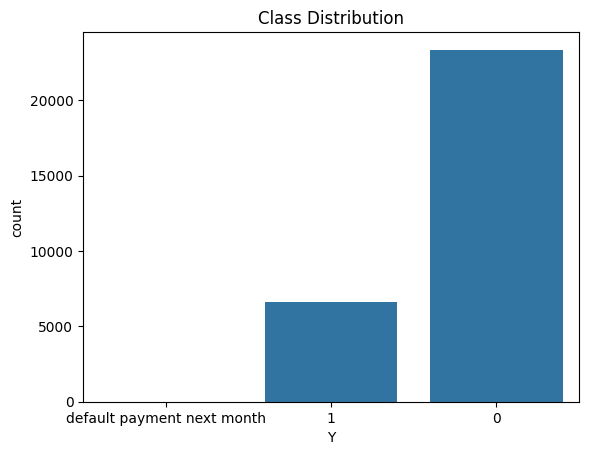

In [ ]:
#visualisation
#class Distribution
sns.countplot(data=ds,x='Y')
plt.title("Class Distribution")
plt.show()

In [ ]:
#Heatmap
ds = ds.apply(pd.to_numeric, errors='coerce')
ds.isnull().sum()
ds=ds.dropna(axis=0)

In [ ]:
ds.dtypes

Unnamed: 0    float64
X1            float64
X2            float64
X3            float64
X4            float64
X5            float64
X6            float64
X7            float64
X8            float64
X9            float64
X10           float64
X11           float64
X12           float64
X13           float64
X14           float64
X15           float64
X16           float64
X17           float64
X18           float64
X19           float64
X20           float64
X21           float64
X22           float64
X23           float64
Y             float64
dtype: object

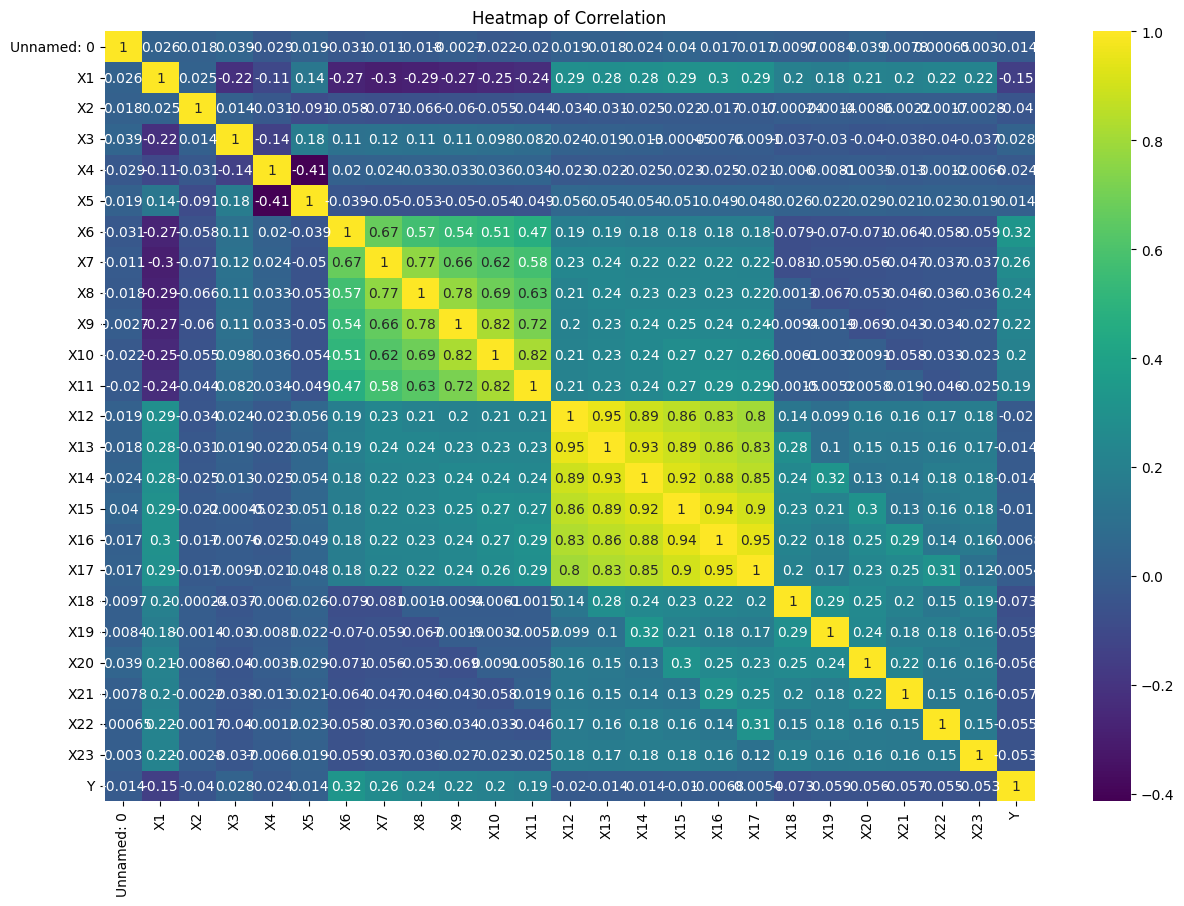

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(ds.corr(),cmap='viridis',annot=True)
plt.title("Heatmap of Correlation")
plt.show()

C:\Users\LOQ\AppData\Local\Temp\ipykernel_14560\68578551.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ds['X1'],bins=50,kde=True)


<Axes: xlabel='X1', ylabel='Density'>

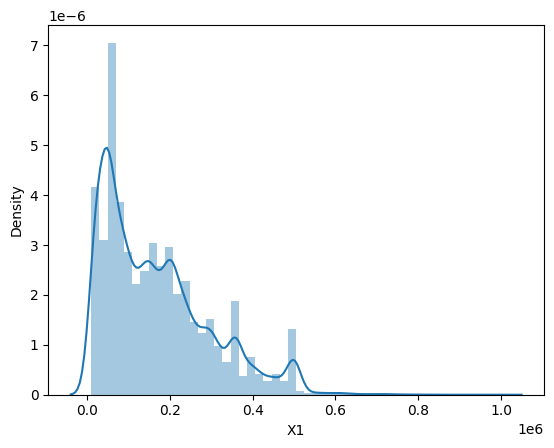

In [ ]:

#feature Distribution
sns.distplot(ds['X1'],bins=50,kde=True)

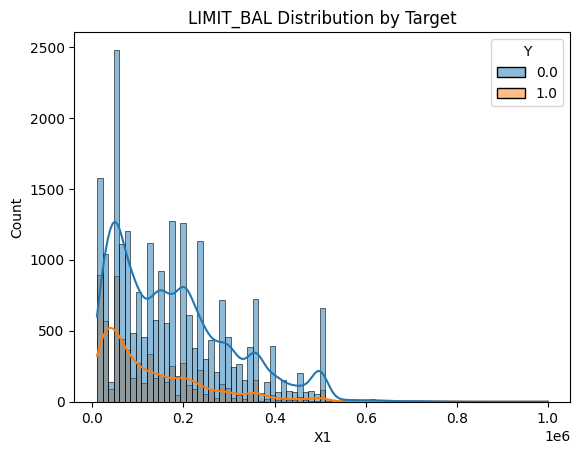

In [ ]:
sns.histplot(data=ds, x="X1", hue="Y", kde=True)
plt.title("LIMIT_BAL Distribution by Target")
plt.show()

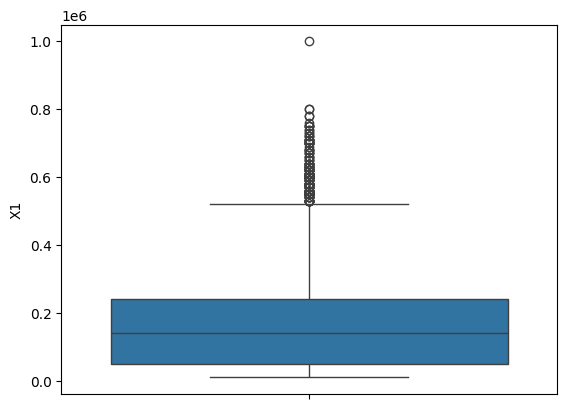

In [ ]:
sns.boxplot(ds['X1'])
plt.show()

In [ ]:
"""plt.figure(figsize=(20,10))
sns.pairplot(ds)"""

'plt.figure(figsize=(20,10))\nsns.pairplot(ds)'

In [ ]:
#train test split
X=ds.drop("Y",axis=1)
y=ds['Y']
print(X)
print(y)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

       Unnamed: 0        X1   X2   X3   X4    X5   X6   X7   X8   X9  ...  \
1             1.0   20000.0  2.0  2.0  1.0  24.0  2.0  2.0 -1.0 -1.0  ...   
2             2.0  120000.0  2.0  2.0  2.0  26.0 -1.0  2.0  0.0  0.0  ...   
3             3.0   90000.0  2.0  2.0  2.0  34.0  0.0  0.0  0.0  0.0  ...   
4             4.0   50000.0  2.0  2.0  1.0  37.0  0.0  0.0  0.0  0.0  ...   
5             5.0   50000.0  1.0  2.0  1.0  57.0 -1.0  0.0 -1.0  0.0  ...   
...           ...       ...  ...  ...  ...   ...  ...  ...  ...  ...  ...   
29996     29996.0  220000.0  1.0  3.0  1.0  39.0  0.0  0.0  0.0  0.0  ...   
29997     29997.0  150000.0  1.0  3.0  2.0  43.0 -1.0 -1.0 -1.0 -1.0  ...   
29998     29998.0   30000.0  1.0  2.0  2.0  37.0  4.0  3.0  2.0 -1.0  ...   
29999     29999.0   80000.0  1.0  3.0  1.0  41.0  1.0 -1.0  0.0  0.0  ...   
30000     30000.0   50000.0  1.0  2.0  1.0  46.0  0.0  0.0  0.0  0.0  ...   

            X14      X15      X16      X17      X18      X19      X20     X

In [ ]:
#Apply Smote function
smote=SMOTE(random_state=42)
X_train_bal,y_train_bal=smote.fit_resample(X_train,y_train)


C:\Users\LOQ\anaconda3\envs\tf_env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [ ]:
# Apply Scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train_bal)
X_test_scaled=scaler.transform(X_test)


In [ ]:
#Logistic Regression
lg=LogisticRegression(penalty='l2',solver='lbfgs',C=1.0)
lg.fit(X_train_scaled,y_train_bal)

LogisticRegression()

In [ ]:
y_pred_lg=lg.predict(X_test_scaled)
y_prob_lg = lg.predict_proba(X_test)[:,1]

C:\Users\LOQ\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
# KNN
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train_bal)

KNeighborsClassifier()

In [ ]:
y_pred_knn=knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test)[:,1]

C:\Users\LOQ\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [ ]:
#Decision Tree
DT=DecisionTreeClassifier(criterion='gini',random_state=42)
DT.fit(X_train_bal,y_train_bal)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt=DT.predict(X_test)
y_prob_dt=DT.predict_proba(X_test)[:,1]

In [ ]:
"""plt.figure(figsize=(10,6))
plot_tree(DT,max_depth=25)
plt.show()"""

'plt.figure(figsize=(10,6))\nplot_tree(DT,max_depth=25)\nplt.show()'

In [ ]:
#Random Forest
rfc=RandomForestClassifier(n_estimators=200,random_state=42)
rfc.fit(X_train_bal,y_train_bal)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred_rfc=rfc.predict(X_test)
y_prob_rfc=rfc.predict_proba(X_test)[:,1]

In [ ]:
#SVM
svm=SVC(kernel='linear',probability=True)
svm.fit(X_train_scaled,y_train_bal)

SVC(kernel='linear', probability=True)

In [ ]:
y_pred_svm=svm.predict(X_test_scaled)
y_prob_svm =svm.predict_proba(X_test)[:,1]

C:\Users\LOQ\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [ ]:
#Naive bayes
nb=BernoulliNB()
nb.fit(X_train_scaled,y_train_bal)

BernoulliNB()

In [ ]:
y_pred_nb=nb.predict(X_test_scaled)
y_prob_nb=nb.predict_proba(X_test)[:,1]

C:\Users\LOQ\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but BernoulliNB was fitted without feature names
  warnings.warn(


In [ ]:
#Gradient Boosting
gb=GradientBoostingClassifier()
gb.fit(X_train_bal,y_train_bal)

GradientBoostingClassifier()

In [ ]:
y_pred_gb=gb.predict(X_test)
y_prob_gb =gb.predict_proba(X_test)[:,1]

In [ ]:
#XGBoost
xg=XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=10)
xg.fit(X_train_bal,y_train_bal)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
y_pred_xg=xg.predict(X_test)
y_prob_xg= xg.predict_proba(X_test)[:,1]

In [ ]:
#evaluation
def evaluate_model(name,y_test,y_pred,y_prob):
  print(f"\n{name} Evaluation")
  print("accuracy_score:",accuracy_score(y_test,y_pred))
  print("precision score:",precision_score(y_test,y_pred))
  print("recall score:",recall_score(y_test,y_pred))
  print("f1 score:",f1_score(y_test,y_pred))
  print("ROC-AUC :",roc_auc_score(y_test,y_prob))
  print("confusion matrix:\n",confusion_matrix(y_test,y_pred))
  print("Classification report:\n",classification_report(y_test,y_pred))

In [ ]:
evaluate_model("Logistic Regression",y_test,y_pred_lg,y_prob_lg)
evaluate_model("K nearest Neighbors",y_test,y_pred_knn,y_prob_knn)
evaluate_model("Decision Tree",y_test,y_pred_dt,y_prob_dt)
evaluate_model("Random Forest",y_test,y_pred_rfc,y_prob_rfc)
evaluate_model("SVM",y_test,y_pred_svm,y_prob_svm)
evaluate_model("Naive Bayes",y_test,y_pred_nb,y_prob_nb)
evaluate_model("Gradient Boosting",y_test,y_pred_gb,y_prob_gb)
evaluate_model("XGBoost",y_test,y_pred_xg,y_prob_xg)


Logistic Regression Evaluation
accuracy_score: 0.692
precision score: 0.37798594847775174
recall score: 0.6081386586284853
f1 score: 0.4662045060658579
ROC-AUC : 0.5000109658476737
confusion matrix:
 [[3345 1328]
 [ 520  807]]
Classification report:
               precision    recall  f1-score   support

         0.0       0.87      0.72      0.78      4673
         1.0       0.38      0.61      0.47      1327

    accuracy                           0.69      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.69      0.71      6000


K nearest Neighbors Evaluation
accuracy_score: 0.7076666666666667
precision score: 0.383397050791917
recall score: 0.5290128108515448
f1 score: 0.44458518049398354
ROC-AUC : 0.4764701936165543
confusion matrix:
 [[3544 1129]
 [ 625  702]]
Classification report:
               precision    recall  f1-score   support

         0.0       0.85      0.76      0.80      4673
         1.0       0.38      0.53      0.44     

NameError: name 'y_pred_rfc' is not defined

In [ ]:
#evaluation table
results = []

def evaluate_model(name, y_test, y_pred,y_prob):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    Roc_auc_score=roc_auc_score(y_test,y_prob)

    results.append([name, acc, prec, rec, f1,Roc_auc_score])

evaluate_model("Logistic Regression",y_test,y_pred_lg,y_prob_lg)
evaluate_model("K nearest Neighbors",y_test,y_pred_knn,y_prob_knn)
evaluate_model("Decision Tree",y_test,y_pred_dt,y_prob_dt)
evaluate_model("Random Forest",y_test,y_pred_rfc,y_prob_rfc)
evaluate_model("SVM",y_test,y_pred_svm,y_prob_svm)
evaluate_model("Naive Bayes",y_test,y_pred_nb,y_prob_nb)
evaluate_model("Gradient Boosting",y_test,y_pred_gb,y_prob_gb)
evaluate_model("XGBoost",y_test,y_pred_xg,y_prob_xg)

results_df = pd.DataFrame(results,
                          columns=["Model","Accuracy","Precision","Recall","F1 Score","Roc_Auc_score"])

results_df

In [ ]:
LogisticRegression()
lg={'penalty' : ['l1', 'l2', 'elasticnet', None],'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],'random_state':[x for x in range(1,100)],'C':[np.linspace(0.01,10,100)]}
RS=RandomizedSearchCV(LogisticRegression(),param_distributions=lg)

In [ ]:
lg=LogisticRegression()

In [ ]:
RS.fit(X_train_scaled,y_train_bal)

In [ ]:
RS.best_pa